# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Evan Wu

**ID**: 5839048

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\evant\OneDrive\Documents\GitHub\hw3-evtw`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Streeter-Phelps solution:
$$ U\frac{dC}{dx} = k_a(C_s-C) + P - R - S_B - k_c B_0 exp(\frac{-k_cx}{U}) - k_n N_0 exp(\frac{-k_nx}{U}) $$

In this model, we ignore $P,R,S_B$. 
$$ U\frac{dC}{dx} = k_a(C_s-C) - k_c B_0 exp(\frac{-k_cx}{U}) - k_n N_0 exp(\frac{-k_nx}{U}) $$
From the known variables:
$$ k_a = \frac{0.55}{day}$$
$$ k_c = \frac{0.35}{day}$$
$$ k_n = \frac{0.25}{day}$$
$$ U = \frac{6km}{day}$$
$$ C_s = 10 \frac{mg}{L}$$

Need to split the system into two parts: the stream before Stream 2 is integrated and the river after Stream 2 is added:

Integrating the equation:
$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 $$
$$ \alpha_1 = exp(-\frac{k_ax}{U}) $$
$$ \alpha_2 = (\frac{k_c}{k_a-k_c})[exp(-\frac{k_cx}{U})-exp(-\frac{k_ax}{U})] $$
$$ \alpha_3 = (\frac{k_n}{k_a-k_n})[exp(-\frac{k_nx}{U})-exp(-\frac{k_ax}{U})] $$

Need to find the initial concentration $C_0$ when $x=0$. Let $x=0$ when the river and Stream 1 just mix:

$$ \alpha_1 = e^{-0} = 1$$
$$ \alpha_2 = (\frac{k_c}{k_a-k_c})(1-1) = 0$$
$$ \alpha_3 = (\frac{k_n}{k_a-k_n})(1-1) = 0$$
$$ C(x) = C_0 $$

Initial concentration of $C_0,B_0,N_0$:

$$ C_0 = 7.5 \frac{mg}{L} \times \frac{10}{11} + 5 \frac{mg}{L} \times \frac{1}{11} \approx 7.27 \frac{mg}{L} $$
$$ B_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 50 \frac{mg}{L} \times \frac{1}{11} \approx 9.09 \frac{mg}{L} $$
$$ N_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 35 \frac{mg}{L} \times \frac{1}{11} \approx 7.73 \frac{mg}{L} $$

Next, we need to consider the system after Stream 2 is added when x = 15km. First, the concentration of the river before Stream 2 is added must be calculated:
$$ C(x=15) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 $$
$$ \alpha_1 = e^{-\frac{0.55\times 15}{6}} \approx 0.252$$
$$ \alpha_2 = \frac{0.35}{0.55-0.35}(e^{-\frac{0.35\times15}{6}}-e^{-\frac{0.55\times15}{6}}) \approx 0.287$$
$$ \alpha_3 = \frac{0.25}{0.55-0.25}(e^{-\frac{0.25\times15}{6}}-e^{-\frac{0.55\times15}{6}}) \approx 0.235$$
Calculating the concentration of the river before Stream 2 is added:
$$ C(x=15) = 10(1-0.252) + 7.27(0.252) - 9.09(0.287) - 7.73(0.235) \approx 4.89 \frac{mg}{L}$$

New system equation after Stream 2 is added:
$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 $$
$$ \alpha_1 = exp(-\frac{k_a(x-15)}{U}) $$
$$ \alpha_2 = (\frac{k_c}{k_a-k_c})[exp(-\frac{k_c(x-15)}{U})-exp(-\frac{k_a(x-15)}{U})] $$
$$ \alpha_3 = (\frac{k_n}{k_a-k_n})[exp(-\frac{k_n(x-15)}{U})-exp(-\frac{k_a(x-15)}{U})] $$
We subtract x by 15 as the mixing starts at x = 15. The initial concentrations after the river and Stream 2 need to be calculated:
$$ C_0 = 4.89 \frac{mg}{L} \times \frac{110}{125} + 5 \frac{mg}{L} \times \frac{15}{125} \approx 4.90 \frac{mg}{L}$$
$$ B_0 = 9.09(1-0.287) \frac{mg}{L} \times \frac{110}{125} + 45 \frac{mg}{L} \times \frac{15}{125} \approx 11.10 \frac{mg}{L}$$
$$ B_0 = 7.73(1-0.235) \frac{mg}{L} \times \frac{110}{125} + 35 \frac{mg}{L} \times \frac{15}{125} \approx 9.40 \frac{mg}{L}$$
With these two system equations, it is possible to plot the dissolved oxygen concentration over distance downstream using a for loop and continually generating values of DO down the river.

2.8358280713478363


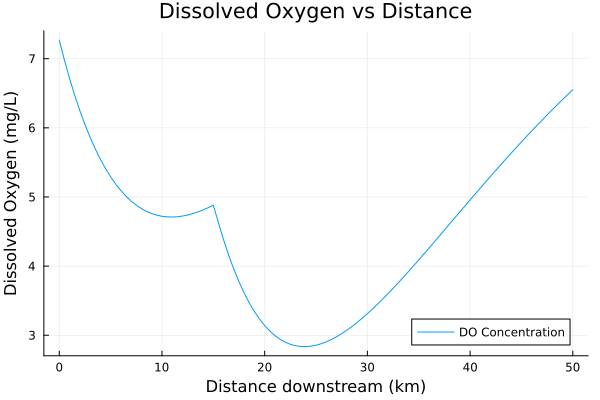

In [3]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

# System 1:
C1_0 = 7.27 # mg/L
B1_0 = 9.09 # mg/L
N1_0 = 7.73 # mg/L

# System 2:
C2_0 = 4.90 # mg/L
B2_0 = 11.10 # mg/L
N2_0 = 9.40 # mg/L

distance_range = [0:0.5:50;];
DO_values = [];

for d in distance_range
    if d <= 15
        alpha1 = exp(-k_a * d / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
        
        C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
        push!(DO_values, C)
    else
        d_adjusted = d - 15
        alpha1 = exp(-k_a * d_adjusted / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

        C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
        push!(DO_values, C)
    end
end

println(minimum(DO_values))
plot(distance_range, DO_values, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration",legend=true)

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Numerical integrated solution will be utilizing the Forward Euler discretization.
$$ U\frac{dC}{dx} = k_a(C_s-C) - k_c B_0 exp(\frac{-k_cx}{U}) - k_n N_0 exp(\frac{-k_nx}{U}) $$
$$ \frac{dC}{dx} = \frac{k_a}{U}(C_s-C) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U}) $$

$$ As \frac{dC}{dx}\approx\frac{\Delta C(x)}{\Delta{x}}=\frac{C(x+\Delta t)-C(x)}{\Delta x}$$
$$ \frac{C(x+\Delta t)-C(x)}{\Delta x} = \frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U}) $$
$$ C(x+\Delta t)-C(x) = \Delta x [\frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U})] $$
$$ C(x+\Delta t) = C(x) + \Delta x [\frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U})] $$

For t = 0.5,
$$ C(x+0.5) = C(x) + 0.5[\frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_cx}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_nx}{U})] $$

When Stream 2 is added (x >= 15), the equation will change:
$$ C_0 = C(x = 15) * \frac{110}{125} + 5 * \frac{15}{125}$$
$$ B_0 = B(x = 15) * \frac{110}{125} + 45 * \frac{15}{125}$$
$$ N_0 = N(x = 15) * \frac{110}{125} + 45 * \frac{15}{125}$$

$$ C(x+\Delta t) = C(x) + \Delta x [\frac{k_a}{U}(C_s-C(x)) - \frac{k_c}{U} B_0 exp(\frac{-k_c(x-15)}{U}) - \frac{k_n}{U} N_0 exp(\frac{-k_n(x-15)}{U})] $$

After, by creating functions to simulate the values of the timestep and concentration, the numerical solution can be plotted and compared to the analytical solution.

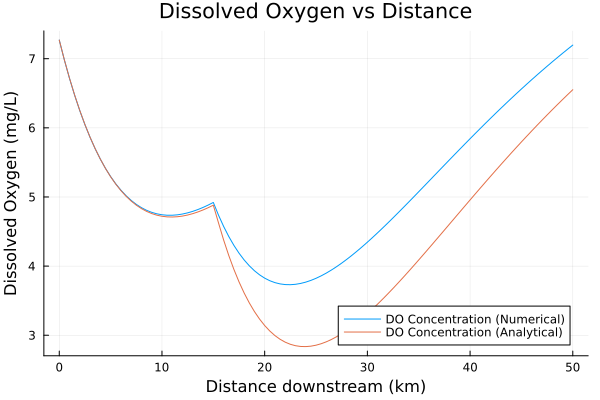

In [4]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

function simulate_timestep1(C, i, C0, B0, N0)
    return k_a/U*(C_s - C) - k_c/U*B0*exp(-k_c*i/U) - k_n/U*N0*exp(-k_n*i/U)
end

function simulate_timestep2(C, i, C0, B0, N0)
    return k_a/U*(C_s - C) - k_c/U*B0*exp(-k_c*(i-15)/U) - k_n/U*N0*exp(-k_n*(i-15)/U)
end

function simulate_wastewater(C0, B0, N0, distance, dx)
    steps = Int64(distance / dx)
    C = zeros(steps + 1)
    C[1] = C0
    for i in 1:steps
        if i*dx <= 15
            C[i+1] = C[i] + dx * simulate_timestep1(C[i], i*dx, C0, B0, N0)
        else
            if i*dx == 15
                C0 = C[i]*110/125 + 5*15/125
                B0 = (B0 - B0*exp(-k_c*i/U))*110/125 + 45*15/125
                N0 = (N0 - N0*exp(-k_c*i/U))*110/125 + 45*15/125
            end
            C[i+1] = C[i] + dx * simulate_timestep2(C[i], i*dx, C0, B0, N0)
        end
    end
    return C
end

simulate_wastewater(7.27, 9.09, 7.73, 50, 0.5)

plot(distance_range, simulate_wastewater(7.27, 9.09, 7.73, 50, 0.5), xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration (Numerical)",legend=true)
plot!(distance_range, DO_values, label="DO Concentration (Analytical)",legend=true)

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Have to adjust the initial concentrations $C_0,B_0,N_0$ for both control volumes before Stream 2 is added and after. Provided that there is a 5% margin of safety, the absolute limit is 3.8 mg/L. 
We'll start with the scenario when waste is treated by 50%. 

Initial concentration of $C_0,B_0,N_0$ before Stream 2 is added:

$$ C_0 = 7.5 \frac{mg}{L} \times \frac{10}{11} + 5 \frac{mg}{L} \times 0.5 \times \frac{1}{11} \approx 7.05 \frac{mg}{L} $$
$$ B_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 50 \frac{mg}{L} \times 0.5 \times \frac{1}{11} \approx 6.82 \frac{mg}{L} $$
$$ N_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 35 \frac{mg}{L} \times 0.5 \times \frac{1}{11} \approx 6.14 \frac{mg}{L} $$

$$ C(x) = C_s(1-\alpha_1) + C_0\alpha_1 - B_0\alpha_2 - N_0\alpha_3 $$
$$ \alpha_1 = e^{-\frac{0.55\times 15}{6}} \approx 0.252$$
$$ \alpha_2 = \frac{0.35}{0.55-0.35}(e^{-\frac{0.35\times15}{6}}-e^{-\frac{0.55\times15}{6}}) \approx 0.287$$
$$ \alpha_3 = \frac{0.25}{0.55-0.25}(e^{-\frac{0.25\times15}{6}}-e^{-\frac{0.55\times15}{6}}) \approx 0.235$$

Concentration at x = 15:
$$ C(x=15) = 10(1-0.252) + 7.05(0.252) - 6.82(0.287) - 6.14(0.235) \approx 5.85 \frac{mg}{L}$$

Initial concentration of $C_0,B_0,N_0$ after Stream 2 is added, assume that Stream 2 is not changed:

$$ C_0 = 5.85 \frac{mg}{L} \times \frac{110}{125} + 5 \frac{mg}{L} \times \frac{15}{125} \approx 5.75 \frac{mg}{L} $$
$$ B_0 = 6.82(1 - 0.287) \frac{mg}{L} \times \frac{110}{125} + 45 \frac{mg}{L} \times \frac{15}{125} \approx 9.68 \frac{mg}{L} $$
$$ N_0 = 6.14(1- 0.235) \frac{mg}{L} \times \frac{110}{125} + 35 \frac{mg}{L} \times 0.5 \times \frac{15}{125} \approx 8.79 \frac{mg}{L} $$


3.8133967134609676


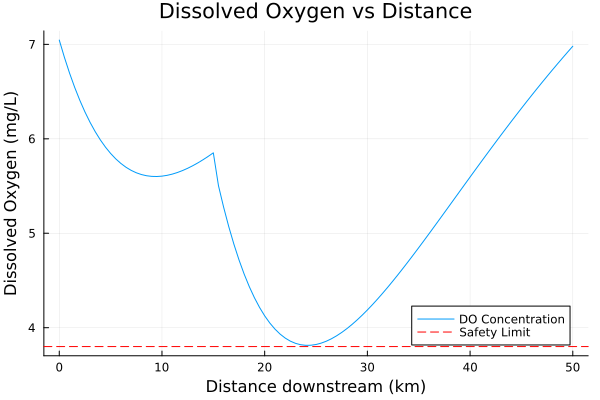

In [5]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

# System 1:
C1_0 = 7.5 * 10/11 + 5 * 0.5 * 1/11 # mg/L
B1_0 = 5 * 10/11 + 50 * 0.5 * 1/11 # mg/L
N1_0 = 5 * 10/11 + 35 * 0.5 * 1/11 # mg/L

# System 2:
C2_0 = (10(1-0.252) + C1_0*0.252 - B1_0*0.287 - N1_0*0.235) * 110/125 + 5 * 15/125 # mg/L
B2_0 = B1_0*(1 - 0.287) * 110/125 + 45 * 15/125 # mg/L
N2_0 = N1_0*(1 - 0.235) * 110/125 + 35 * 15/125 # mg/L

distance_range = [0:0.5:50;];
DO_values = [];

for d in distance_range
    if d <= 15
        alpha1 = exp(-k_a * d / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
        
        C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
        push!(DO_values, C)
    else
        d_adjusted = d - 15
        alpha1 = exp(-k_a * d_adjusted / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

        C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
        push!(DO_values, C)
    end
end

minimum(DO_values)
println(minimum(DO_values))
plot(distance_range, DO_values, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration",legend=true)
hline!([3.8], label="Safety Limit", linestyle=:dash, color=:red)

Since this example fortunately skimmed the absolute safety limit in the first try, only one additional test is necessary by confirming if slightly decreasing the treatment % to 49% will make the system still meet the safety limits. 

3.7938260915969124


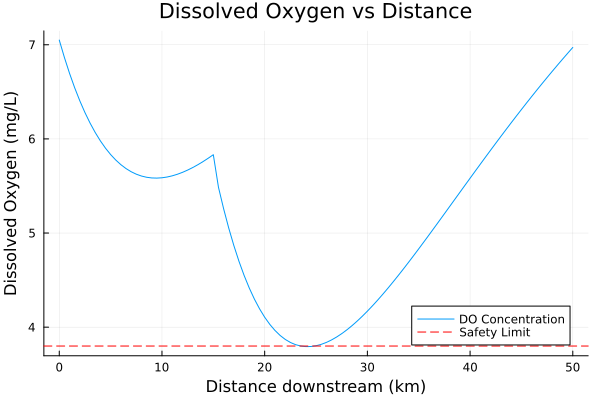

In [6]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

# System 1:
C1_0 = 7.5 * 10/11 + 5 * 0.51 * 1/11 # mg/L
B1_0 = 5 * 10/11 + 50 * 0.51 * 1/11 # mg/L
N1_0 = 5 * 10/11 + 35 * 0.51 * 1/11 # mg/L

# System 2:
C2_0 = (10(1-0.252) + C1_0*0.252 - B1_0*0.287 - N1_0*0.235) * 110/125 + 5 * 15/125 # mg/L
B2_0 = B1_0*(1 - 0.287) * 110/125 + 45 * 15/125 # mg/L
N2_0 = N1_0*(1 - 0.235) * 110/125 + 35 * 15/125 # mg/L

distance_range = [0:0.5:50;];
DO_values = [];

for d in distance_range
    if d <= 15
        alpha1 = exp(-k_a * d / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
        
        C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
        push!(DO_values, C)
    else
        d_adjusted = d - 15
        alpha1 = exp(-k_a * d_adjusted / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

        C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
        push!(DO_values, C)
    end
end

minimum(DO_values)
println(minimum(DO_values))
plot(distance_range, DO_values, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration",legend=true)
hline!([3.8], label="Safety Limit", linestyle=:dash, color=:red)

As decreasing the % removal of waste to 49% does not meet the absolute safety limit, therefore the minimum percentage of waste to be removed must be at 50%. 

For the scenario where only Stream 2 is treated, the initial concentrations $C_0,B_0,N_0$ and the concentration at x = 15 will be the same as Problem 1.1:
$$ C_0 = 7.5 \frac{mg}{L} \times \frac{10}{11} + 5 \frac{mg}{L} \times \frac{1}{11} \approx 7.27 \frac{mg}{L} $$
$$ B_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 50 \frac{mg}{L} \times \frac{1}{11} \approx 9.09 \frac{mg}{L} $$
$$ N_0 = 5 \frac{mg}{L} \times \frac{10}{11} + 35 \frac{mg}{L} \times \frac{1}{11} \approx 7.73 \frac{mg}{L} $$
Concentration at x = 15:
$$ C(x=15) = 10(1-0.252) + 7.05(0.252) - 6.82(0.287) - 6.14(0.235) \approx 5.85 \frac{mg}{L}$$

Initial concentrations $C_0,B_0,N_0$ after Stream 2 is mixed in will be different based on the amount treated. As a starter, a reduction of 50% will be conducted:
$$ C_0 = 5.85 \frac{mg}{L} \times \frac{110}{125} + 5 \frac{mg}{L} \times \frac{15}{125} \times 0.5 $$
$$ B_0 = 9.09(1-0.287) \frac{mg}{L} \times \frac{110}{125} + 45 \frac{mg}{L} \times \frac{15}{125} \times 0.5 $$
$$ N_0 = 7.73(1-0.235) \frac{mg}{L} \times \frac{110}{125} + 35 \frac{mg}{L} \times \frac{15}{125} \times 0.5 $$

3.7760111801567486


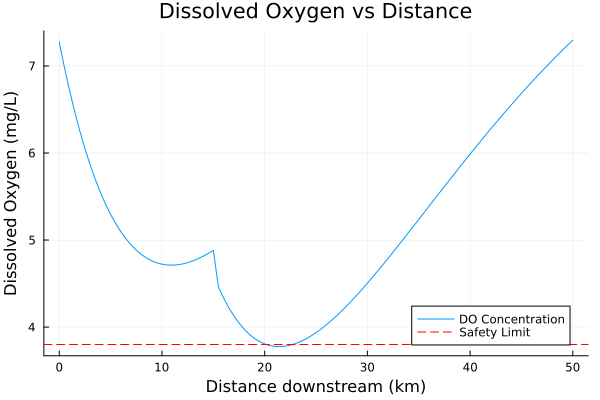

In [7]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

# System 1:
C1_0 = 7.5 * 10/11 + 5 * 1/11 # mg/L
B1_0 = 5 * 10/11 + 50 * 1/11 # mg/L
N1_0 = 5 * 10/11 + 35 * 1/11 # mg/L

# System 2:
C2_0 = (10(1-0.252) + C1_0*0.252 - B1_0*0.287 - N1_0*0.235) * 110/125 + 5 * 15/125 * 0.5 # mg/L
B2_0 = B1_0*(1 - 0.287) * 110/125 + 45 * 15/125 * 0.5 # mg/L
N2_0 = N1_0*(1 - 0.235) * 110/125 + 35 * 15/125 *0.5 # mg/L

distance_range = [0:0.5:50;];
DO_values = [];

for d in distance_range
    if d <= 15
        alpha1 = exp(-k_a * d / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
        
        C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
        push!(DO_values, C)
    else
        d_adjusted = d - 15
        alpha1 = exp(-k_a * d_adjusted / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

        C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
        push!(DO_values, C)
    end
end

minimum(DO_values)
println(minimum(DO_values))
plot(distance_range, DO_values, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration",legend=true)
hline!([3.8], label="Safety Limit", linestyle=:dash, color=:red)

From this simulation, it appears that the system only drops below the safety limit for a small period. Therefore, an additional trial will be conducted where the minimum waste reduced is increased by 52%.

3.809411846219514


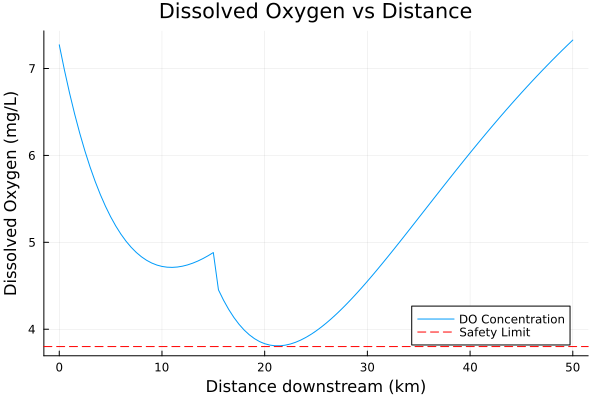

In [8]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

# System 1:
C1_0 = 7.5 * 10/11 + 5 * 1/11 # mg/L
B1_0 = 5 * 10/11 + 50 * 1/11 # mg/L
N1_0 = 5 * 10/11 + 35 * 1/11 # mg/L

# System 2:
C2_0 = (10(1-0.252) + C1_0*0.252 - B1_0*0.287 - N1_0*0.235) * 110/125 + 5 * 15/125 * 0.48 # mg/L
B2_0 = B1_0*(1 - 0.287) * 110/125 + 45 * 15/125 * 0.48 # mg/L
N2_0 = N1_0*(1 - 0.235) * 110/125 + 35 * 15/125 *0.48 # mg/L

distance_range = [0:0.5:50;];
DO_values = [];

for d in distance_range
    if d <= 15
        alpha1 = exp(-k_a * d / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
        
        C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
        push!(DO_values, C)
    else
        d_adjusted = d - 15
        alpha1 = exp(-k_a * d_adjusted / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

        C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
        push!(DO_values, C)
    end
end

minimum(DO_values)
println(minimum(DO_values))
plot(distance_range, DO_values, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration",legend=true)
hline!([3.8], label="Safety Limit", linestyle=:dash, color=:red)

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

3.8226341788166613


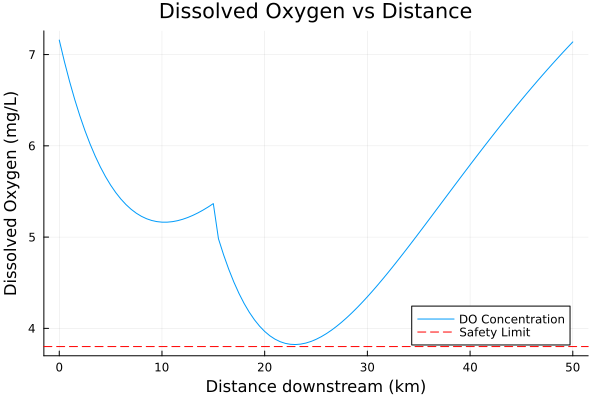

In [9]:
# Equation constants:
k_a = 0.55
k_c = 0.35
k_n = 0.25
C_s = 10 # mg/L
U = 6 # km/d

# System 1:
C1_0 = 7.5 * 10/11 + 5 * 1/11 * 0.75 # mg/L
B1_0 = 5 * 10/11 + 50 * 1/11 * 0.75 # mg/L
N1_0 = 5 * 10/11 + 35 * 1/11 * 0.75 # mg/L

# System 2:
C2_0 = (10(1-0.252) + C1_0*0.252 - B1_0*0.287 - N1_0*0.235) * 110/125 + 5 * 15/125 * 0.75 # mg/L
B2_0 = B1_0*(1 - 0.287) * 110/125 + 45 * 15/125 * 0.75 # mg/L
N2_0 = N1_0*(1 - 0.235) * 110/125 + 35 * 15/125 *0.75 # mg/L

distance_range = [0:0.5:50;];
DO_values = [];

for d in distance_range
    if d <= 15
        alpha1 = exp(-k_a * d / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
        
        C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
        push!(DO_values, C)
    else
        d_adjusted = d - 15
        alpha1 = exp(-k_a * d_adjusted / U)
        alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
        alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

        C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
        push!(DO_values, C)
    end
end

minimum(DO_values)
println(minimum(DO_values))
plot(distance_range, DO_values, xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)", title="Dissolved Oxygen vs Distance", label="DO Concentration",legend=true)
hline!([3.8], label="Safety Limit", linestyle=:dash, color=:red)

Based on the simulations, it is preferable to treat Stream 2 alone. Since the percentage of waste removed from either stream has similar effects on the magnitude and distance that the minimum value occurs, other considerations about how DO changes through the river should be analyzed. One consideration is the difference in magnitude that DO concentration changes when Stream 2 is added when only Stream 2 is treated vs both streams. When Stream 1 is treated, the DO concentration remains at higher levels from 0km to 15km, but drops significantly after Stream 2 is added. This drastic change in DO could be harmful as it could affect the behaviours of aquatic organisms at that point in the river, even if DO eventually increases later downstream.

Some other information that may be a factor in making a conclusion could be financial and energy costs of treating each stream. Since the effects of removing waste from each stream is similar, if one method of treatment ends up costing less than the other, then that method would be preferred.  

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

Any[3.8420142812609206, 3.7317431237849377, 3.852844818814084, 3.8635971391949027, 3.965228837907817, 4.009116893022279, 3.695170870385958, 3.761008369828419, 3.8724557676243765, 3.9543721507990024, 3.932199982387487, 3.8508090121089693, 3.9575675495837355, 3.7686818140707867, 3.69420897347352, 3.847355219769106, 3.6929654032589454, 3.739864529946521, 3.80497872311493, 3.8051962437583295, 3.893245467126247, 3.632272900434304, 3.715203780469013, 3.8424645910107347, 3.8311044876899967, 3.831699787671102, 3.981451719269875, 3.7981310755814786, 3.819800871684551, 3.8183576854983787, 3.7404045949524285, 3.6977510854271802, 3.879164884437239, 3.827109945710026, 3.8752484759308046, 3.783087930401873, 3.917301191244476, 3.9277524212356467, 3.8599183243412614, 3.6890249621160667, 3.688596330619715, 3.86033158628793, 3.784476434334584, 3.7951567144998606, 3.731258440527931, 3.8650460100096313, 3.880490012721571, 3.899156767683889, 4.007317683163691, 3.871369403875924, 3.637861535971226, 3.780914

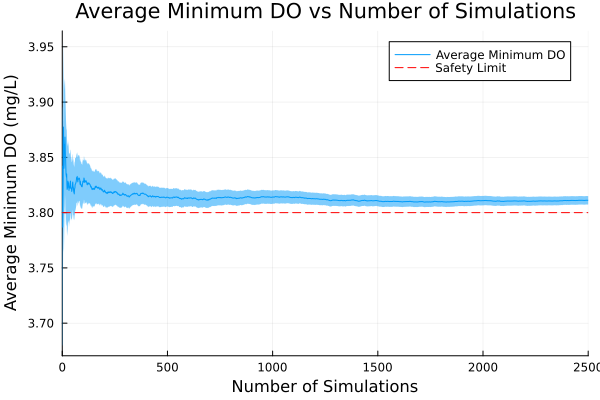

In [15]:
DO_dist = LogNormal(2.0,0.15)
sample_size = 2500
DO_samples = rand(DO_dist, sample_size)
final_DO_values = [];

for i in 1:sample_size
    # Equation constants:
    k_a = 0.55
    k_c = 0.35
    k_n = 0.25
    C_s = 10 # mg/L
    U = 6 # km/d

    # System 1:
    C1_0 = DO_samples[i] * 10/11 + 5 * 0.5 * 1/11 # mg/L
    B1_0 = 5 * 10/11 + 50 * 0.5 * 1/11 # mg/L
    N1_0 = 5 * 10/11 + 35 * 0.5 * 1/11 # mg/L

    # System 2:
    C2_0 = (10(1-0.252) + C1_0*0.252 - B1_0*0.287 - N1_0*0.235) * 110/125 + 5 * 15/125 # mg/L
    B2_0 = B1_0*(1 - 0.287) * 110/125 + 45 * 15/125 # mg/L
    N2_0 = N1_0*(1 - 0.235) * 110/125 + 35 * 15/125 # mg/L

    distance_range = [0:0.5:50;];
    DO_values = [];

    for d in distance_range
        if d <= 15
            alpha1 = exp(-k_a * d / U)
            alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d / U) - exp(-k_a * d / U))
            alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d / U) - exp(-k_a * d / U))
            
            C = C_s*(1-alpha1) + C1_0*alpha1 - B1_0*alpha2 - N1_0*alpha3
            push!(DO_values, C)
        else
            d_adjusted = d - 15
            alpha1 = exp(-k_a * d_adjusted / U)
            alpha2 = (k_c / (k_a - k_c)) * (exp(-k_c * d_adjusted / U) - exp(-k_a * d_adjusted / U))
            alpha3 = (k_n / (k_a - k_n)) * (exp(-k_n * d_adjusted / U) - exp(-k_a * d_adjusted / U))

            C = C_s*(1-alpha1) + C2_0*alpha1 - B2_0*alpha2 - N2_0*alpha3
            push!(DO_values, C)
        end
    end
    push!(final_DO_values, minimum(DO_values))
end

print(final_DO_values)
avg_DO = zeros(length(final_DO_values))
std_DO = zeros(length(final_DO_values))
std_DO[1] = 0.0
for j in 1:length(final_DO_values)
    avg_DO[j] = mean(final_DO_values[1:j])
    std_DO[j] = std(final_DO_values[1:j]) / sqrt(j)
end
plot(1:length(final_DO_values), avg_DO, ribbon=1.96 * std_DO, xlim=(0, length(final_DO_values)), xlabel="Number of Simulations", ylabel="Average Minimum DO (mg/L)", title="Average Minimum DO vs Number of Simulations", label="Average Minimum DO",legend=true)
hline!([3.8], label="Safety Limit", linestyle=:dash, color=:red)

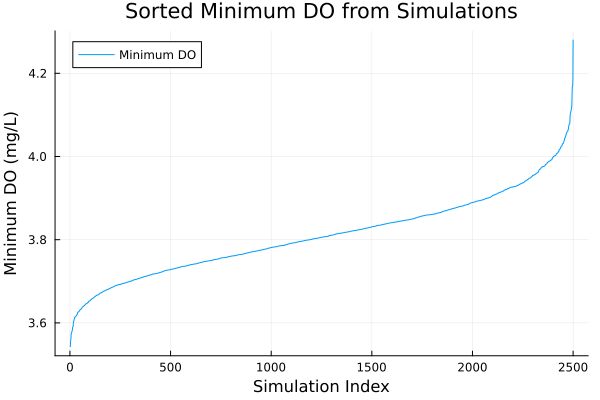

In [16]:
sorted_DO = sort(final_DO_values)
plot(sorted_DO, xlabel="Simulation Index", ylabel="Minimum DO (mg/L)", title="Sorted Minimum DO from Simulations", label="Minimum DO",legend=true)

## References

List any external references consulted, including classmates.